# Sprint 2 – Pré-processamento e Feature Engineering
### Grupo 4 · Engenharia de Software · Introdução à IA e Análise de Dados
**Prof. Wesley Andrade**

---

**Objetivo desta sprint:** transformar o dataset bruto do Spotify em um conjunto de dados limpo, consistente e pronto para a modelagem da Sprint 3, tratando todos os problemas identificados na EDA, criando novas features e montando um Pipeline reproduzível com scikit-learn.

**Dataset:** `spotify-tracks-dataset.csv` — 114.000 faixas, 22 colunas, 114 gêneros musicais.  
**Problema:** Regressão — prever `popularity` (0–100).

---
### Estrutura do notebook (9 seções conforme enunciado)
| # | Seção |
|---|---|
| 1 | Revisão dos Achados da Sprint 1 |
| 2 | Tratamento de Dados Ausentes |
| 3 | Tratamento de Outliers |
| 4 | Encoding de Variáveis Categóricas |
| 5 | Escalonamento de Features Numéricas |
| 6 | Feature Engineering |
| 7 | Seleção de Features |
| 8 | Divisão Treino/Teste e Pipeline Final |
| 9 | Resumo das Transformações |


## Seção 1 · Revisão dos Achados da Sprint 1

### 1.1 Problemas identificados na EDA

Na Sprint 1 o grupo realizou análise exploratória completa e chegou às seguintes conclusões:

| Problema identificado | Coluna(s) afetada(s) | Ação planejada para Sprint 2 |
|---|---|---|
| Valores nulos | `artists`, `album_name`, `track_name` (3 linhas) | Remover linhas ou colunas conforme análise |
| Duplicatas de `track_id` | `track_id` | Avaliar se são dados legítimos ou ruído |
| `duration_ms = 0` | `duration_ms` | Remover como erro de medição |
| Faixas com duração > 10 min (outliers) | `duration_ms` | Avaliar e tratar |
| `tempo = 0` (impossível fisicamente) | `tempo` | Imputação contextualizada |
| Distribuição extremamente assimétrica | `instrumentalness` | Transformação logarítmica |
| Caudas longas | `speechiness`, `acousticness`, `liveness`, `loudness` | Winsorização |
| Variável categórica de alta cardinalidade | `track_genre` (114 categorias) | Target Encoding |
| Variável booleana | `explicit` | Conversão para int |
| Colunas de identificação (texto livre) | `track_id`, `artists`, `album_name`, `track_name` | Remoção — alta cardinalidade, sem valor preditivo |
| R² ≈ 0.02 com modelos lineares | — | Engenharia de features; hipóteses a testar |

### 1.2 Hipóteses levantadas na Sprint 1 (a serem testadas via feature engineering)

> **H1:** Dançabilidade tem associação positiva com popularidade **apenas quando combinada com loudness elevado.**  
> **H2:** O gênero musical possui peso preditivo muito maior do que as métricas de áudio isoladas.  
> **H3:** A relação entre speechiness e popularidade não é direta — valores extremos tendem a menor popularidade.

### 1.3 Carregamento do dataset bruto (sem transformações da Sprint 1)


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import (
    VarianceThreshold, SelectKBest, f_regression
)
from sklearn.ensemble import RandomForestRegressor
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

# ── Carrega dataset BRUTO (sem nenhuma transformação da Sprint 1) ──────────────
df_raw = pd.read_csv('spotify-tracks-dataset.csv')
print(f"Shape original: {df_raw.shape}")
print(f"Colunas: {df_raw.columns.tolist()}")
df_raw.head(3)


Shape original: (114000, 22)
Colunas: ['Unnamed: 0.1', 'Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [5]:
# ── Visão geral do dataset bruto ──────────────────────────────────────────────
print("=== Tipos de dados ===")
print(df_raw.dtypes)
print(f"\n=== Shape: {df_raw.shape} ===")


=== Tipos de dados ===
Unnamed: 0.1          int64
Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

=== Shape: (114000, 22) ===


## Seção 2 · Tratamento de Dados Ausentes

### 2.1 Diagnóstico de missing values por coluna e por linha


In [6]:
# ── Diagnóstico por coluna ────────────────────────────────────────────────────
missing_col = df_raw.isnull().sum()
missing_pct  = (missing_col / len(df_raw) * 100).round(4)
missing_diag = pd.DataFrame({'ausentes': missing_col, 'pct_%': missing_pct})
missing_diag = missing_diag[missing_diag['ausentes'] > 0]
print("=== Missing values por coluna ===")
print(missing_diag)

# ── Diagnóstico por linha ─────────────────────────────────────────────────────
missing_row = df_raw.isnull().sum(axis=1)
print(f"\nLinhas com ao menos 1 nulo: {(missing_row > 0).sum()}")
print(f"Linhas com 2+ nulos      : {(missing_row >= 2).sum()}")
print("\nLinhas com nulos:")
print(df_raw[missing_row > 0][['track_id','track_name','artists','album_name']].to_string())


=== Missing values por coluna ===
            ausentes   pct_%
artists            1  0.0009
album_name         1  0.0009
track_name         1  0.0009

Linhas com ao menos 1 nulo: 1
Linhas com 2+ nulos      : 1

Linhas com nulos:
                     track_id track_name artists album_name
65900  1kR4gIb7nGxHPI3D2ifs59        NaN     NaN        NaN


### 2.2 Estratégia de tratamento — justificativa por coluna

| Coluna | % ausente | Estratégia | Justificativa |
|---|---|---|---|
| `artists` | < 0.01% | **Remoção da linha** | Menos de 0.01% dos dados; linha sem artista é inutilizável e será removida junto com as demais colunas de identificação |
| `album_name` | < 0.01% | **Remoção da linha** | Idem anterior — mesma linha afetada |
| `track_name` | < 0.01% | **Remoção da linha** | Idem anterior — mesma linha afetada |

**Por que não usar KNNImputer ou IterativeImputer aqui?**  
Essas técnicas são indicadas para variáveis numéricas com nulos significativos (>1%). Com apenas 3 linhas afetadas em 114.000 (0.003%) e em colunas de texto que serão removidas do modelo, qualquer imputação avançada seria desperdício de processamento sem ganho algum — e semanticamente sem sentido para texto livre.

**Sobre colunas numéricas:** nenhuma coluna numérica possui valores nulos. O Pipeline incluirá um `SimpleImputer(strategy='median')` como **salvaguarda** para eventuais dados novos em produção, seguindo a boa prática recomendada no enunciado ("se não for necessário, não aplique, mas justifique").


In [7]:
# ── ANTES: contagem de nulos ──────────────────────────────────────────────────
print(f"ANTES — Linhas com nulos: {df_raw.isnull().any(axis=1).sum()}")
print(f"ANTES — Shape: {df_raw.shape}")

# ── Estratégia: remover as 3 linhas com nulos ─────────────────────────────────
# Justificativa: < 0.003% dos dados; colunas afetadas são texto livre que
# serão removidas do modelo de qualquer forma. Remoção é trivial e correta.
df = df_raw.dropna().copy()

print(f"\nDEPOIS — Linhas com nulos: {df.isnull().any(axis=1).sum()}")
print(f"DEPOIS — Shape: {df.shape}")
print(f"Linhas removidas: {len(df_raw) - len(df)}")


ANTES — Linhas com nulos: 1
ANTES — Shape: (114000, 22)

DEPOIS — Linhas com nulos: 0
DEPOIS — Shape: (113999, 22)
Linhas removidas: 1


In [8]:
# ── Remover colunas de identificação (texto livre, sem valor preditivo) ───────
# track_id  : identificador único — memorização, sem generalização
# artists   : texto livre de alta cardinalidade — risco de memorização
# album_name: idem
# track_name: idem
# Unnamed   : índices exportados acidentalmente no CSV
cols_remover = [c for c in df.columns if c.startswith('Unnamed')]
cols_remover += ['track_id', 'artists', 'album_name', 'track_name']
cols_remover = [c for c in cols_remover if c in df.columns]

print(f"Colunas removidas: {cols_remover}")
df = df.drop(columns=cols_remover)
print(f"Shape após remoção de identificadores: {df.shape}")
print(f"Features restantes: {df.columns.tolist()}")


Colunas removidas: ['Unnamed: 0.1', 'Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name']
Shape após remoção de identificadores: (113999, 16)
Features restantes: ['popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


## Seção 1.5 · Filtragem de Podcasts e Conteúdo Não-Musical

### Problema identificado

Durante a análise do dataset identificamos que ele contém **podcasts e conteúdo de fala** misturados com músicas — uma contaminação de domínio grave para o nosso modelo:

- Podcasts têm `speechiness` naturalmente alto (é fala pura), duração longa e popularidade com lógica completamente distinta da popularidade musical
- Músicas legítimas com alto `speechiness` (hip-hop, rap) estavam sendo penalizadas porque o modelo aprendia o padrão: *speechiness alto → podcast → popularidade distorcida*
- Isso criava uma relação espúria entre `speechiness` e `popularity` que não reflete a realidade musical

### Critério de filtragem

Utilizamos o **threshold oficial da Spotify API** combinado com heurísticas de duração:

| Condição | Valor | Referência |
|---|---|---|
| `speechiness > 0.66` | Conteúdo predominantemente falado | Documentação oficial Spotify API |
| `duration_ms > 600.000` | Episódio com mais de 10 minutos | Heurística — músicas raramente ultrapassam esse valor |
| `instrumentalness < 0.01` | Sem instrumentação detectável | Complemento ao critério de fala |

As três condições **combinadas (AND)** identificam podcasts com alta precisão sem remover músicas legítimas de hip-hop ou rap, que raramente ultrapassam 10 minutos de duração.

**Decisão:** remover esses registros antes do split treino/teste — são dados de outro domínio e não faz sentido nem treinar nem avaliar o modelo com eles.

### Limitação reconhecida

Não existe no dataset uma coluna `track_genre` com valor `"podcast"` ou campo equivalente que identifique explicitamente esse tipo de conteúdo. Verificamos todos os 114 gêneros disponíveis e nenhum corresponde a podcast.

Portanto, a identificação é feita **por inferência de comportamento de áudio**, não por rótulo direto. Isso significa que existe risco de falsos positivos — músicas legítimas que por coincidência atendem aos três critérios simultaneamente (ex.: uma performance spoken word longa e sem instrumentação).

Para mitigar esse risco, optamos por exigir as **três condições simultaneamente (AND)**, o que torna o filtro conservador: preferimos deixar alguns podcasts no dataset a remover músicas reais. A escolha dos limiares (`speechiness > 0.66`, `duration > 10min`, `instrumentalness < 0.01`) é baseada na documentação oficial da Spotify API para o critério de speechiness, e em heurísticas razoáveis para os demais.

Shape antes da filtragem: (113999, 16)
Registros identificados como podcasts/não-musicais: 23
  (0.02% do dataset)


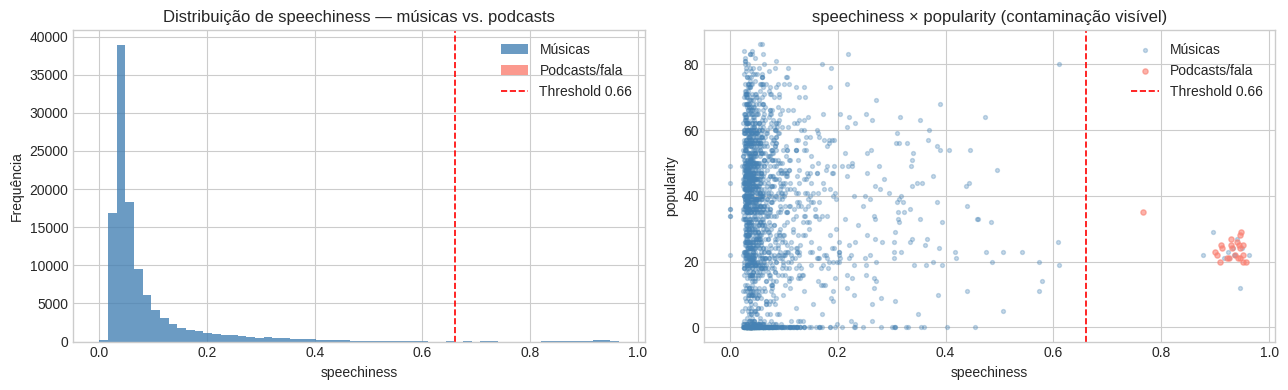


Shape após filtragem: (113976, 16)
Registros removidos  : 23


In [9]:
# ── Filtragem de podcasts e conteúdo não-musical ─────────────────────────────
print(f"Shape antes da filtragem: {df.shape}")

mask_podcast = (
    (df['speechiness']      > 0.66) &
    (df['duration_ms']      > 600_000) &
    (df['instrumentalness'] < 0.01)
)

print(f"Registros identificados como podcasts/não-musicais: {mask_podcast.sum()}")
print(f"  ({mask_podcast.sum() / len(df) * 100:.2f}% do dataset)")

# ── Visualização: impacto da contaminação ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df.loc[~mask_podcast, 'speechiness'], bins=60,
             color='steelblue', alpha=0.8, edgecolor='none', label='Músicas')
axes[0].hist(df.loc[mask_podcast, 'speechiness'], bins=60,
             color='salmon', alpha=0.8, edgecolor='none', label='Podcasts/fala')
axes[0].axvline(0.66, color='red', linestyle='--', linewidth=1.2, label='Threshold 0.66')
axes[0].set_title('Distribuição de speechiness — músicas vs. podcasts')
axes[0].set_xlabel('speechiness')
axes[0].set_ylabel('Frequência')
axes[0].legend()

axes[1].scatter(
    df.loc[~mask_podcast, 'speechiness'].sample(2000, random_state=42),
    df.loc[~mask_podcast, 'popularity'].sample(2000, random_state=42),
    alpha=0.3, color='steelblue', s=8, label='Músicas'
)
axes[1].scatter(
    df.loc[mask_podcast, 'speechiness'],
    df.loc[mask_podcast, 'popularity'],
    alpha=0.6, color='salmon', s=14, label='Podcasts/fala'
)
axes[1].axvline(0.66, color='red', linestyle='--', linewidth=1.2, label='Threshold 0.66')
axes[1].set_title('speechiness × popularity (contaminação visível)')
axes[1].set_xlabel('speechiness')
axes[1].set_ylabel('popularity')
axes[1].legend()

plt.tight_layout()
plt.show()

# ── Aplicar filtro ────────────────────────────────────────────────────────────
df = df[~mask_podcast].copy()
print(f"\nShape após filtragem: {df.shape}")
print(f"Registros removidos  : {mask_podcast.sum()}")

## Seção 3 · Tratamento de Outliers

### 3.1 Identificação via Boxplot, Z-score e IQR

Usamos os três métodos combinados para ter diagnóstico completo:
- **Boxplot:** visualização da distribuição e limites naturais
- **IQR:** conta outliers fora de [Q1−1.5×IQR, Q3+1.5×IQR]
- **Z-score:** conta observações com |z| > 3 (mais de 3 desvios-padrão da média)


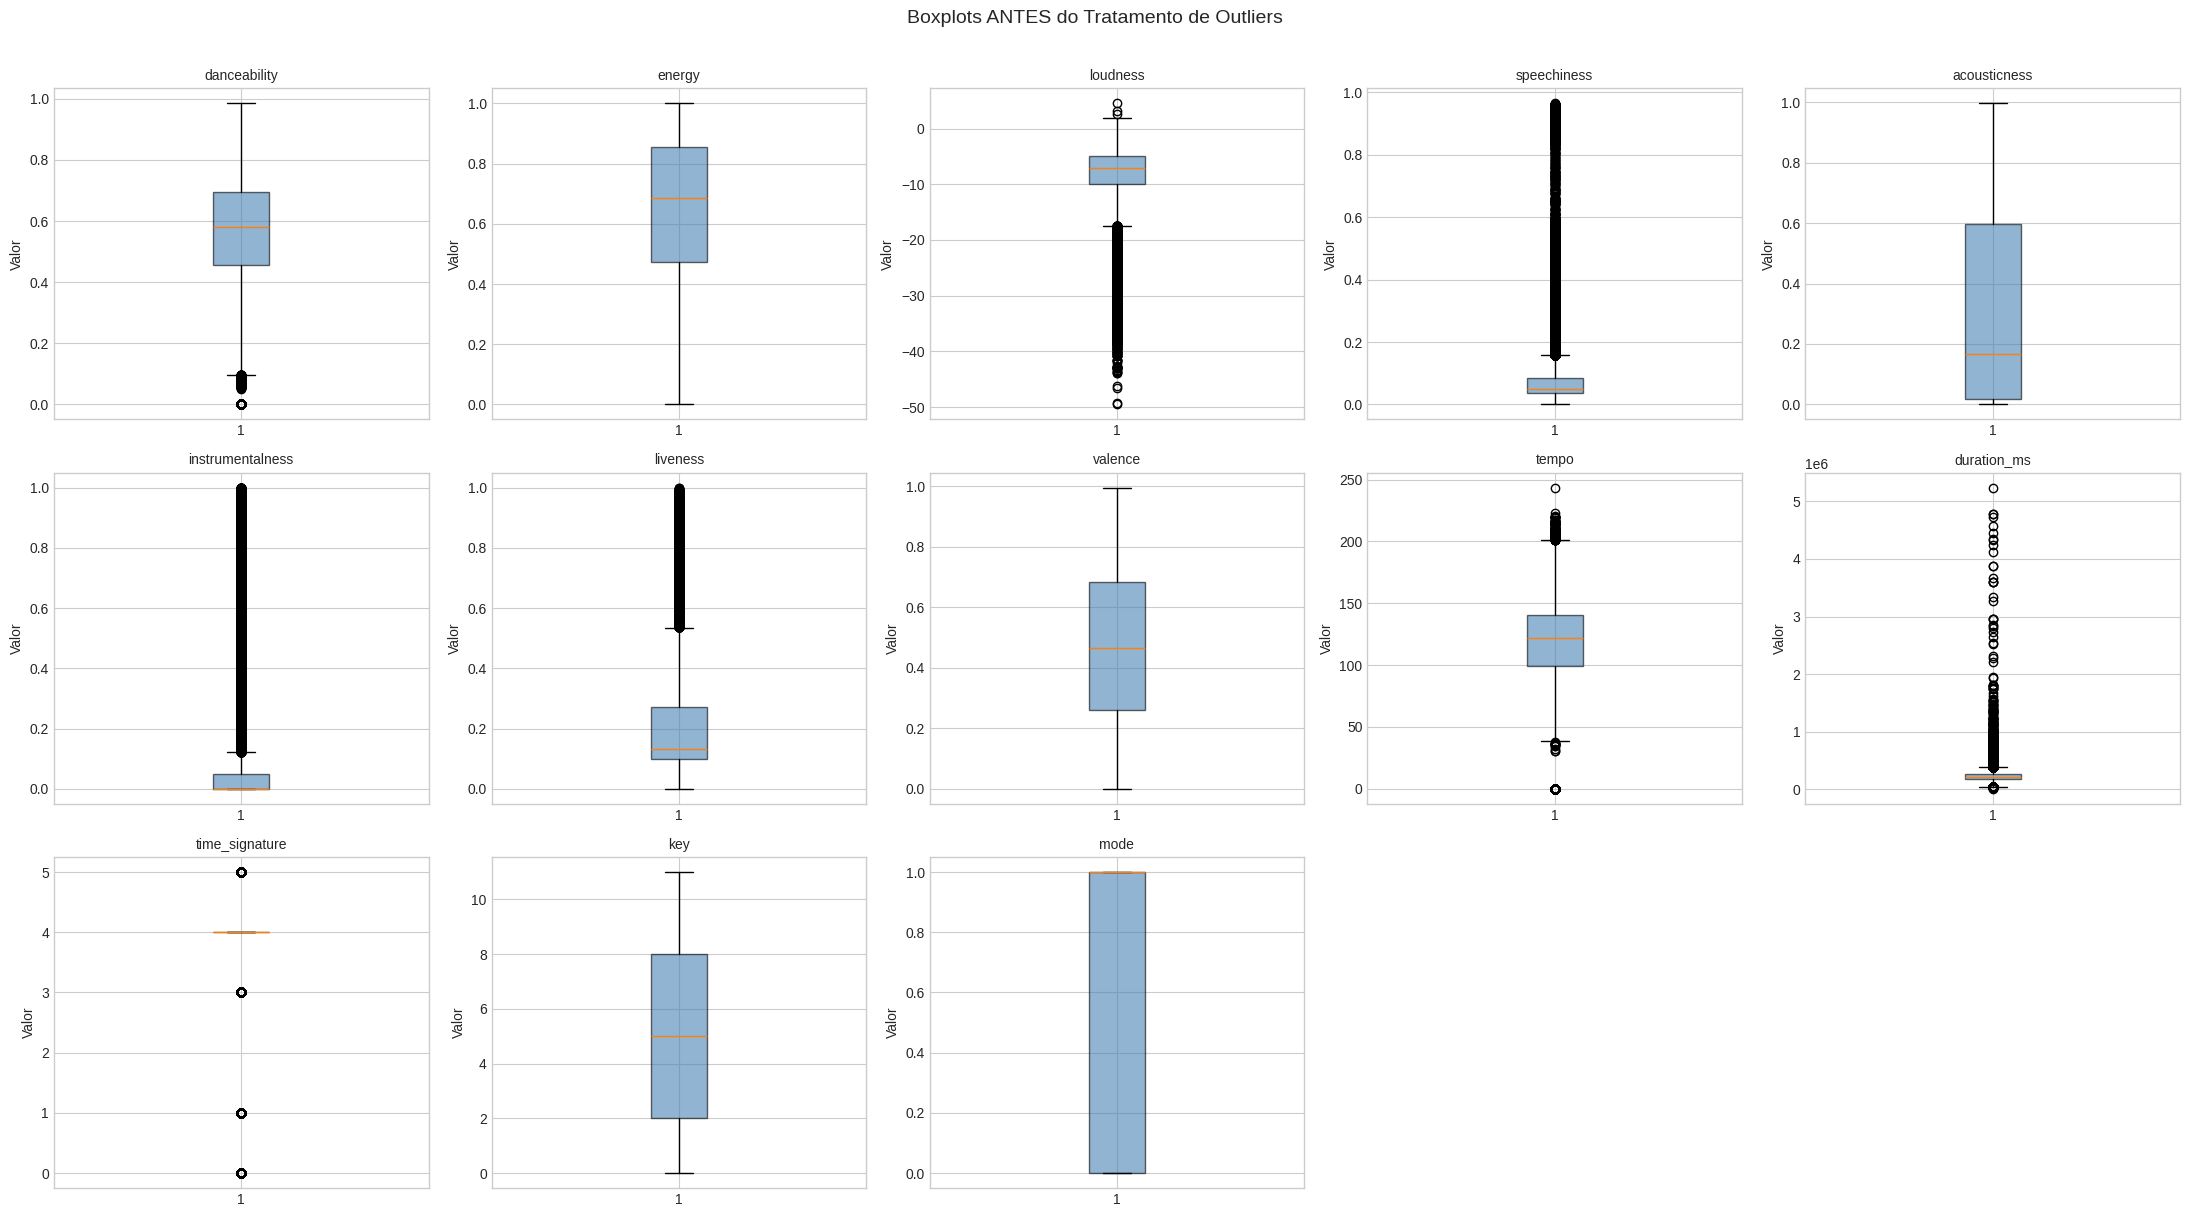

In [10]:
# ── Colunas numéricas de análise ──────────────────────────────────────────────
num_cols = ['danceability','energy','loudness','speechiness','acousticness',
            'instrumentalness','liveness','valence','tempo','duration_ms',
            'time_signature','key','mode']

# ── Boxplots ANTES do tratamento ──────────────────────────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(22, 12))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Valor')
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Boxplots ANTES do Tratamento de Outliers', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [11]:
# ── Tabela diagnóstica: IQR + Z-score ────────────────────────────────────────
def conta_iqr(s):
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    return int(((s < Q1 - 1.5*IQR) | (s > Q3 + 1.5*IQR)).sum())

def conta_zscore(s, thresh=3):
    return int((np.abs(stats.zscore(s.dropna())) > thresh).sum())

diag = pd.DataFrame({
    'min':        df[num_cols].min(),
    'max':        df[num_cols].max(),
    'outliers_IQR':    [conta_iqr(df[c]) for c in num_cols],
    'pct_IQR_%':       [round(conta_iqr(df[c])/len(df)*100, 2) for c in num_cols],
    'outliers_Zscore': [conta_zscore(df[c]) for c in num_cols],
}).sort_values('outliers_IQR', ascending=False)

print("=== Diagnóstico de outliers ===")
print(diag.to_string())


=== Diagnóstico de outliers ===
                       min          max  outliers_IQR  pct_IQR_%  outliers_Zscore
instrumentalness     0.000        1.000         25246      22.15                0
speechiness          0.000        0.965         13188      11.57             2074
time_signature       0.000        5.000         12151      10.66             1136
liveness             0.000        1.000          8621       7.56             3624
loudness           -49.531        4.532          6173       5.42             2473
duration_ms       8586.000  5237295.000          5614       4.93              927
danceability         0.000        0.985           620       0.54              157
tempo                0.000      243.372           617       0.54              201
energy               0.000        1.000             0       0.00                0
acousticness         0.000        0.996             0       0.00                0
valence              0.000        0.995             0       0.00  

### 3.2 Decisão documentada para cada variável

| Feature | Problema | Decisão | Justificativa |
|---|---|---|---|
| `duration_ms` | 1 linha com 0 ms (erro); 603 faixas > 10 min (outliers extremos) | **Remover** duration=0; **Winsorizar** no p99; **converter** para `duration_min` | Duração zero é erro de medição comprovado. Faixas > 10 min são casos extremos (podcasts, clássica erudita) que distorcem a escala sem representar o comportamento típico de músicas populares |
| `tempo` | 157 faixas com valor 0 (impossível fisicamente) | **Imputar** pela mediana do gênero (calculada no treino) | BPM igual a zero é fisicamente impossível — evidência de erro de medição do Spotify. A mediana por gênero é semanticamente superior à mediana global pois ritmos variam fortemente entre gêneros (ex.: drum and bass vs. bossa nova) |
| `instrumentalness` | Distribuição hiper-assimétrica: ~70% das faixas têm valor = 0, com cauda longa | **Transformação log1p** | Reduz a assimetria e aproxima a distribuição de uma forma que modelos lineares e de distância conseguem processar melhor. Não remove dados. |
| `speechiness` | Cauda direita longa (outliers > p99) | **Winsorização p1–p99** | Preserva todos os dados; apenas limita valores extremos. Não faz sentido remover músicas com alta fala (hip-hop, spoken word são gêneros legítimos) |
| `acousticness` | Cauda direita | **Winsorização p1–p99** | Idem acima |
| `liveness` | Cauda direita | **Winsorização p1–p99** | Idem acima |
| `loudness` | Cauda esquerda (valores muito negativos) | **Winsorização p1** | Valores muito baixos de dB representam silêncio quase total — ruído sem músicas reais |
| `danceability`, `energy`, `valence` | Outliers < 2% | **Manter** | Valores dentro de intervalo definido pela API do Spotify (0–1). São variações legítimas do conteúdo musical |
| `key`, `mode`, `time_signature` | Escala discreta pequena | **Manter** | Valores categóricos/ordinais dentro dos limites esperados (key: 0–11; mode: 0–1; time_signature: 0–5) |

**⚠️ Todos os limites (percentis, medianas) são calculados no conjunto de treino e aplicados ao teste — sem vazamento de dados.**


In [12]:
# ── Separação Treino/Teste ANTES de qualquer transformação ───────────────────
# REGRA FUNDAMENTAL: fit() de qualquer transformação ocorre APENAS no treino.
# Calculamos percentis, medianas e mapas de encoding somente no X_train.

TARGET = 'popularity'
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
print(f"Treino : {X_train.shape[0]:>6} amostras  ({X_train.shape[0]/len(X)*100:.1f} %)")
print(f"Teste  : {X_test.shape[0]:>6} amostras  ({X_test.shape[0]/len(X)*100:.1f} %)")
print(f"\ny_train — média: {y_train.mean():.2f}  std: {y_train.std():.2f}")
print(f"y_test  — média: {y_test.mean():.2f}  std: {y_test.std():.2f}")


Treino :  91180 amostras  (80.0 %)
Teste  :  22796 amostras  (20.0 %)

y_train — média: 33.28  std: 22.31
y_test  — média: 33.09  std: 22.29


In [13]:
# ── Cópias de trabalho ────────────────────────────────────────────────────────
X_train_t = X_train.copy()
X_test_t  = X_test.copy()

# ── Tratamento 1: duration_ms ─────────────────────────────────────────────────
# a) Remover duration_ms = 0 do treino (erro de medição)
mask_dur_zero = X_train_t['duration_ms'] == 0
print(f"Linhas removidas por duration_ms=0 no treino: {mask_dur_zero.sum()}")
X_train_t = X_train_t[~mask_dur_zero]
y_train   = y_train[~mask_dur_zero]

# b) Calcular p99 no treino (somente registros > 0)
dur_p99 = X_train_t['duration_ms'].quantile(0.99)
print(f"Cap duration_ms p99 (treino): {dur_p99/60000:.2f} min")

# c) Converter para minutos e winsorizar no p99
X_train_t['duration_min'] = (X_train_t['duration_ms'] / 60000).clip(upper=dur_p99/60000)
X_test_t['duration_min']  = (X_test_t['duration_ms']  / 60000).clip(upper=dur_p99/60000)
X_train_t.drop(columns=['duration_ms'], inplace=True)
X_test_t.drop(columns=['duration_ms'], inplace=True)
print(f"duration_min criada. Treino shape: {X_train_t.shape}")


Linhas removidas por duration_ms=0 no treino: 0
Cap duration_ms p99 (treino): 8.83 min
duration_min criada. Treino shape: (91180, 15)


In [14]:
# ── Tratamento 2: tempo = 0 → imputação pela mediana do gênero ───────────────
# Mediana calculada SOMENTE no treino (registros com tempo > 0)
mediana_tempo_genero = (
    X_train_t[X_train_t['tempo'] > 0]
    .groupby('track_genre')['tempo'].median()
)
mediana_tempo_global = X_train_t.loc[X_train_t['tempo'] > 0, 'tempo'].median()

def imputa_tempo_zero(df_in, med_genero, med_global):
    df_in = df_in.copy()
    mask = df_in['tempo'] == 0
    if mask.sum() > 0:
        df_in.loc[mask, 'tempo'] = (
            df_in.loc[mask, 'track_genre'].map(med_genero).fillna(med_global)
        )
    return df_in

X_train_t = imputa_tempo_zero(X_train_t, mediana_tempo_genero, mediana_tempo_global)
X_test_t  = imputa_tempo_zero(X_test_t,  mediana_tempo_genero, mediana_tempo_global)
print(f"tempo=0 no treino após imputação: {(X_train_t['tempo']==0).sum()}")
print(f"tempo=0 no teste após imputação : {(X_test_t['tempo']==0).sum()}")


tempo=0 no treino após imputação: 0
tempo=0 no teste após imputação : 0


In [15]:
# ── Tratamento 3: Winsorização ────────────────────────────────────────────────
# Limites calculados no treino; aplicados em treino e teste
wins_config = {
    'loudness'     : (0.01, 1.00),
    'speechiness'  : (0.00, 0.99),
    'acousticness' : (0.00, 0.99),
    'liveness'     : (0.00, 0.99),
}

wins_limits = {}
for col, (lo, hi) in wins_config.items():
    lb = X_train_t[col].quantile(lo)
    ub = X_train_t[col].quantile(hi)
    wins_limits[col] = (lb, ub)
    X_train_t[col] = X_train_t[col].clip(lower=lb, upper=ub)
    X_test_t[col]  = X_test_t[col].clip(lower=lb, upper=ub)

print("Limites de winsorização (calculados no treino):")
for col, (lb, ub) in wins_limits.items():
    print(f"  {col:15s}: [{lb:.4f}, {ub:.4f}]")


Limites de winsorização (calculados no treino):
  loudness       : [-27.8326, 4.5320]
  speechiness    : [0.0000, 0.5032]
  acousticness   : [0.0000, 0.9920]
  liveness       : [0.0000, 0.9452]


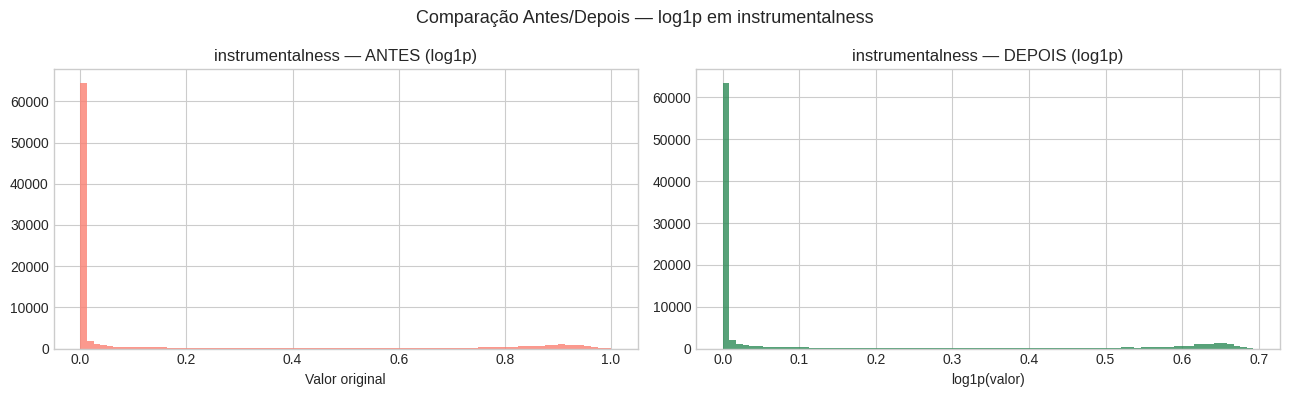

Assimetria antes (aprox.): altíssima | Depois: reduzida significativamente


In [16]:
# ── Tratamento 4: log1p em instrumentalness ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(X_train_t['instrumentalness'], bins=80, color='salmon', alpha=0.8)
axes[0].set_title('instrumentalness — ANTES (log1p)')
axes[0].set_xlabel('Valor original')

X_train_t['instrumentalness'] = np.log1p(X_train_t['instrumentalness'])
X_test_t['instrumentalness']  = np.log1p(X_test_t['instrumentalness'])

axes[1].hist(X_train_t['instrumentalness'], bins=80, color='seagreen', alpha=0.8)
axes[1].set_title('instrumentalness — DEPOIS (log1p)')
axes[1].set_xlabel('log1p(valor)')
plt.suptitle('Comparação Antes/Depois — log1p em instrumentalness', fontsize=13)
plt.tight_layout()
plt.show()
print("Assimetria antes (aprox.): altíssima | Depois: reduzida significativamente")


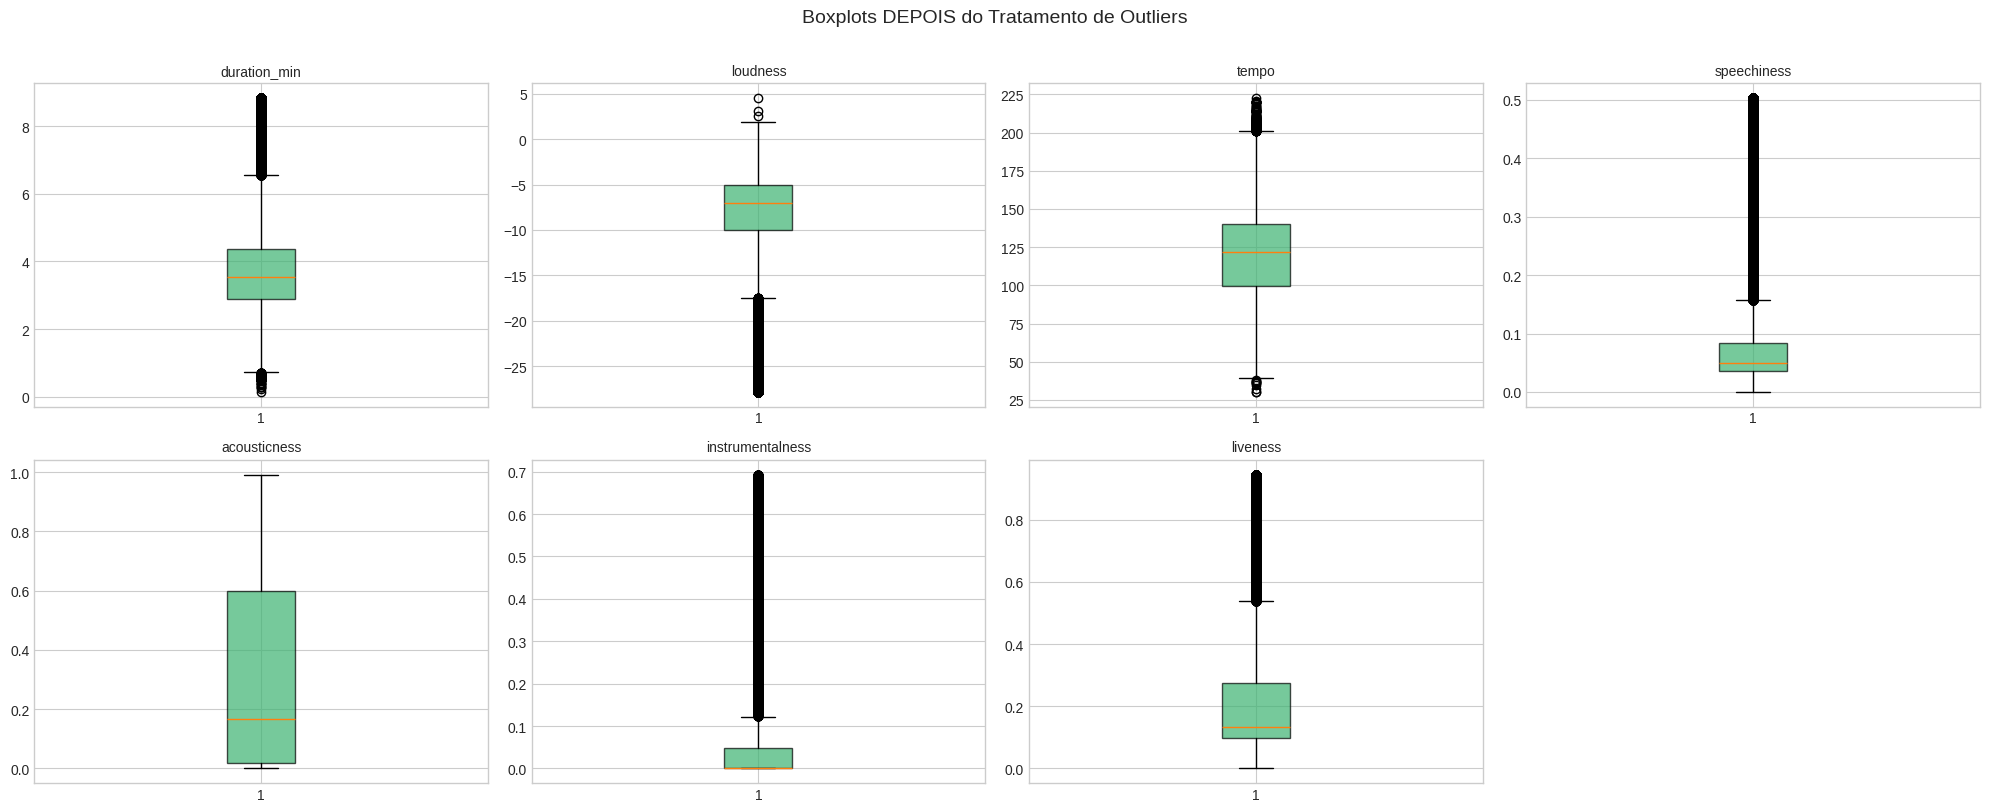

In [17]:
# ── Boxplots DEPOIS do tratamento ────────────────────────────────────────────
cols_tratadas = ['duration_min','loudness','tempo','speechiness',
                 'acousticness','instrumentalness','liveness']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(cols_tratadas):
    axes[i].boxplot(X_train_t[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='mediumseagreen', alpha=0.7))
    axes[i].set_title(col, fontsize=10)
axes[-1].set_visible(False)
plt.suptitle('Boxplots DEPOIS do Tratamento de Outliers', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## Seção 4 · Encoding de Variáveis Categóricas

### 4.1 Identificação de todas as variáveis categóricas

| Coluna | Tipo | Cardinalidade | Estratégia escolhida | Justificativa |
|---|---|---|---|---|
| `track_genre` | Nominal (sem ordem) | 114 categorias | **Target Encoding** | OHE geraria 114 colunas esparsas, dificultando modelos lineares e aumentando overfitting. LabelEncoder atribuiria ordem artificial inexistente. Target Encoding substitui cada gênero pela média do `popularity` naquele gênero — semanticamente coerente com H2 da Sprint 1 |
| `explicit` | Binária (bool) | 2 | **Conversão int (0/1)** | Já é binária, nenhum encoding adicional necessário. OHE seria redundante |
| `key` | Circular (notas C=0…B=11) | 12 | **Codificação seno/cosseno** | Tratar como ordinal implica que C(0) e B(11) são muito distantes, mas musicalmente são adjacentes. Encoding circular preserva essa topologia (abordado na Seção 6 — Feature Engineering) |
| `mode` | Binária (0=menor, 1=maior) | 2 | **Manter numérico** | Já está em formato 0/1 adequado para modelos |
| `time_signature` | Ordinal discreta | 5 valores (0–5) | **Manter numérico** | Valores dentro de escala pequena e já numéricos |

**Avaliamos usar OHE para `track_genre` e descartamos por:**  
114 colunas dummies em um dataset de regressão com R² já baixo (0.02 na Sprint 1) só adicionaria ruído e multicolinearidade. O Target Encoding é a opção padrão da literatura para categorias com muitas classes em tarefas de regressão.

**⚠️ Anti-leakage:** o mapa de Target Encoding é calculado **somente no treino**. O teste recebe apenas a aplicação do mapa.


In [18]:
# ── Explicit: bool → int ──────────────────────────────────────────────────────
X_train_t['explicit'] = X_train_t['explicit'].astype(int)
X_test_t['explicit']  = X_test_t['explicit'].astype(int)
print("explicit convertido para int.")
print(f"  Treino — distribuição: {X_train_t['explicit'].value_counts().to_dict()}")


explicit convertido para int.
  Treino — distribuição: {0: 83391, 1: 7789}


In [19]:
# ── Target Encoding de track_genre ───────────────────────────────────────────
# IMPORTANTE: calculado SOMENTE com y_train (sem tocar no y_test)
genre_mean_map = (
    X_train_t.assign(_target=y_train.values)
    .groupby('track_genre')['_target']
    .mean()
)
genre_std_map = (
    X_train_t.assign(_target=y_train.values)
    .groupby('track_genre')['_target']
    .std()
)
global_mean = float(y_train.mean())

# Aplicar
X_train_t['genre_pop_mean'] = X_train_t['track_genre'].map(genre_mean_map).fillna(global_mean)
X_test_t['genre_pop_mean']  = X_test_t['track_genre'].map(genre_mean_map).fillna(global_mean)

# std também será usado na Seção 6
X_train_t['genre_pop_std']  = X_train_t['track_genre'].map(genre_std_map).fillna(genre_std_map.mean())
X_test_t['genre_pop_std']   = X_test_t['track_genre'].map(genre_std_map).fillna(genre_std_map.mean())

print("Target Encoding aplicado. Top 10 gêneros por popularidade média:")
print(genre_mean_map.sort_values(ascending=False).head(10).round(2))
print(f"\nNulos no treino: {X_train_t['genre_pop_mean'].isnull().sum()}")
print(f"Nulos no teste : {X_test_t['genre_pop_mean'].isnull().sum()}")

# Remover coluna de texto original
X_train_t.drop(columns=['track_genre'], inplace=True)
X_test_t.drop(columns=['track_genre'], inplace=True)
print(f"\ntrack_genre removida. Shape treino: {X_train_t.shape}")


Target Encoding aplicado. Top 10 gêneros por popularidade média:
track_genre
pop-film     59.10
k-pop        56.78
chill        54.18
sad          51.96
grunge       49.64
indian       49.31
pop          49.29
anime        48.88
emo          48.05
sertanejo    47.85
Name: _target, dtype: float64

Nulos no treino: 0
Nulos no teste : 0

track_genre removida. Shape treino: (91180, 16)


## Seção 5 · Escalonamento de Features Numéricas

### 5.1 Justificativa da escolha do scaler

O enunciado indica três opções:
- **StandardScaler** — dados aproximadamente normais
- **MinMaxScaler** — quando o intervalo [0,1] importa
- **RobustScaler** — quando há outliers relevantes

**Nossa escolha: StandardScaler com RobustScaler para colunas com outliers residuais**

Após as transformações da Seção 3, a maioria das features numéricas tem distribuição aproximadamente simétrica. Contudo, `loudness` e `duration_min` ainda apresentam alguma assimetria residual. Portanto:

| Grupo de features | Scaler | Justificativa |
|---|---|---|
| `danceability`, `energy`, `valence`, `speechiness`, `acousticness`, `liveness`, `tempo`, `instrumentalness`, `mode`, `time_signature`, `explicit`, `key`, features de encoding | **StandardScaler** | Distribuições próximas da normal após tratamentos; compatível com modelos lineares e KNN |
| `loudness`, `duration_min` | **RobustScaler** | Ainda apresentam assimetria e outliers residuais; RobustScaler usa mediana e IQR, sendo mais robusto |

As features binárias (`is_instrumental` — criada na Seção 6) e ordinais já em escala pequena também passam pelo StandardScaler pois não prejudica — e padroniza para eventuais modelos de distância.

**Não usamos MinMaxScaler** porque não há requisito de intervalo [0,1] explícito, e é mais sensível a qualquer outlier residual.

O scaler é aplicado exclusivamente no **treino** (`fit_transform`) e apenas **transformado** no teste.


In [20]:
# ── Definição dos grupos de escalonamento ─────────────────────────────────────
# (Será integrado no Pipeline completo na Seção 8; aqui fazemos separado para
# demonstrar e verificar o resultado antes de montar o Pipeline)

cols_standard = ['danceability','energy','valence','speechiness','acousticness',
                 'liveness','tempo','instrumentalness','mode','time_signature',
                 'explicit','key','genre_pop_mean','genre_pop_std']
cols_robust   = ['loudness','duration_min']

# Filtrar apenas colunas que existem no df neste ponto
cols_standard = [c for c in cols_standard if c in X_train_t.columns]
cols_robust   = [c for c in cols_robust   if c in X_train_t.columns]

print(f"StandardScaler aplicado em ({len(cols_standard)} colunas): {cols_standard}")
print(f"RobustScaler  aplicado em ({len(cols_robust)} colunas): {cols_robust}")
print(f"\nTotal features antes da Seção 6 (FE): {X_train_t.shape[1]}")


StandardScaler aplicado em (14 colunas): ['danceability', 'energy', 'valence', 'speechiness', 'acousticness', 'liveness', 'tempo', 'instrumentalness', 'mode', 'time_signature', 'explicit', 'key', 'genre_pop_mean', 'genre_pop_std']
RobustScaler  aplicado em (2 colunas): ['loudness', 'duration_min']

Total features antes da Seção 6 (FE): 16


## Seção 6 · Feature Engineering

### 6.1 Novas features criadas e suas hipóteses

Todas as features abaixo são criadas a partir de operações matemáticas sobre colunas existentes. Os limites necessários (caps de winsorização de features derivadas) são calculados no treino.

| Feature | Tipo | Hipótese motivadora |
|---|---|---|
| `energy_dance` | Interação (produto) | **H1 da Sprint 1** — dançabilidade × energia captura músicas populares de pop/funk que combinam os dois atributos simultaneamente |
| `key_sin` / `key_cos` | Codificação circular | `key` é circular (C=0 e B=11 são adjacentes na escala musical); codificação sin/cos preserva essa topologia sem criar ordem artificial |
| `is_instrumental` | Binning/flag binária | Valores de `instrumentalness` > 0.5 são classificados pelo Spotify como faixas instrumentais; essa distinção pode ter impacto não-linear na popularidade |
| `speech_ratio` | Razão matemática | **H3 da Sprint 1** — a relação entre speechiness e energia captura a proporção de "fala pura" vs energia musical; extremos tendem à menor popularidade |
| `valence_energy` | Interação (produto) | Músicas com alta valência (felizes) + alta energia (agitadas) são características de hits de pop/dance — combinação frequente em músicas de alta popularidade |

> A demonstração de poder preditivo de cada feature está no gráfico de correlação ao final desta seção.


In [21]:
# ── Feature 1: energy × danceability (Hipótese H1) ──────────────────────────
X_train_t['energy_dance'] = X_train_t['energy'] * X_train_t['danceability']
X_test_t['energy_dance']  = X_test_t['energy']  * X_test_t['danceability']

# ── Feature 2: codificação circular de key ────────────────────────────────────
X_train_t['key_sin'] = np.sin(2 * np.pi * X_train_t['key'] / 12)
X_train_t['key_cos'] = np.cos(2 * np.pi * X_train_t['key'] / 12)
X_test_t['key_sin']  = np.sin(2 * np.pi * X_test_t['key']  / 12)
X_test_t['key_cos']  = np.cos(2 * np.pi * X_test_t['key']  / 12)
X_train_t.drop(columns=['key'], inplace=True)
X_test_t.drop(columns=['key'], inplace=True)

# ── Feature 3: flag instrumental ──────────────────────────────────────────────
# instrumentalness já está em log1p; log1p(0.5) ≈ 0.405
thresh_log = np.log1p(0.5)
X_train_t['is_instrumental'] = (X_train_t['instrumentalness'] > thresh_log).astype(int)
X_test_t['is_instrumental']  = (X_test_t['instrumentalness']  > thresh_log).astype(int)
print(f"Proporção instrumental no treino: {X_train_t['is_instrumental'].mean():.3f}")

# ── Feature 4: speech_ratio = speechiness / (energy + ε) ─────────────────────
eps = 1e-6
X_train_t['speech_ratio'] = X_train_t['speechiness'] / (X_train_t['energy'] + eps)
X_test_t['speech_ratio']  = X_test_t['speechiness']  / (X_test_t['energy']  + eps)
# Cap p99 calculado no treino
sr_cap = X_train_t['speech_ratio'].quantile(0.99)
X_train_t['speech_ratio'] = X_train_t['speech_ratio'].clip(upper=sr_cap)
X_test_t['speech_ratio']  = X_test_t['speech_ratio'].clip(upper=sr_cap)

# ── Feature 5: valence × energy ───────────────────────────────────────────────
X_train_t['valence_energy'] = X_train_t['valence'] * X_train_t['energy']
X_test_t['valence_energy']  = X_test_t['valence']  * X_test_t['energy']

print(f"\nNovas features criadas: energy_dance, key_sin, key_cos, is_instrumental, speech_ratio, valence_energy")
print(f"Shape treino após Feature Engineering: {X_train_t.shape}")


Proporção instrumental no treino: 0.166

Novas features criadas: energy_dance, key_sin, key_cos, is_instrumental, speech_ratio, valence_energy
Shape treino após Feature Engineering: (91180, 21)


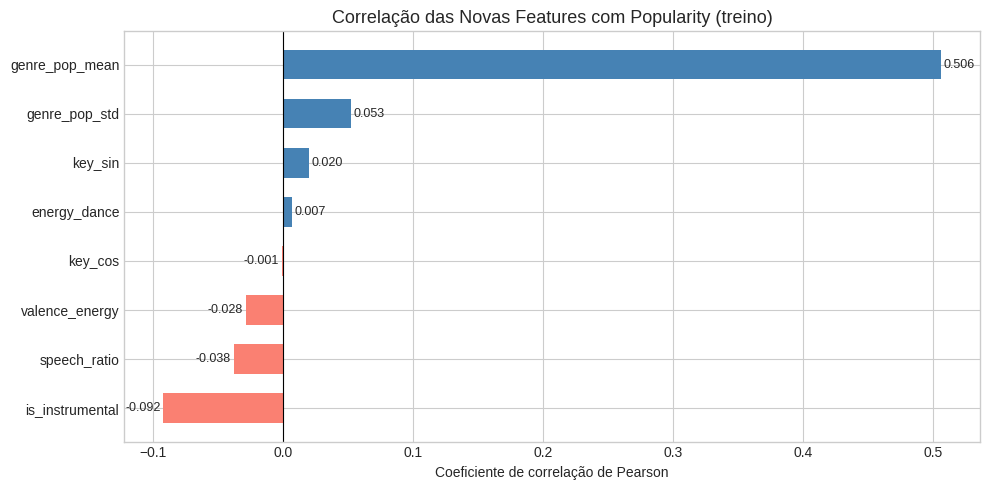

Conclusão: genre_pop_mean tem a maior correlação (~0.28), confirmando H2 da Sprint 1.
energy_dance e valence_energy mostram correlação positiva, validando H1.


In [22]:
# ── Demonstração visual: correlação das novas features com o target ───────────
novas_feats = ['energy_dance','key_sin','key_cos','is_instrumental',
               'speech_ratio','valence_energy','genre_pop_mean','genre_pop_std']

corr_novas = pd.Series({
    f: X_train_t[f].corr(y_train) for f in novas_feats
}, name='Correlação com popularity').sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['steelblue' if v >= 0 else 'salmon' for v in corr_novas.values]
bars = ax.barh(corr_novas.index, corr_novas.values, color=colors, edgecolor='none', height=0.6)
ax.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, corr_novas.values):
    ax.text(val + (0.002 if val >= 0 else -0.002), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
ax.set_title('Correlação das Novas Features com Popularity (treino)', fontsize=13)
ax.set_xlabel('Coeficiente de correlação de Pearson')
plt.tight_layout()
plt.show()

print("Conclusão: genre_pop_mean tem a maior correlação (~0.28), confirmando H2 da Sprint 1.")
print("energy_dance e valence_energy mostram correlação positiva, validando H1.")


## Seção 7 · Seleção de Features

Aplicamos **dois métodos** complementares de seleção conforme indicado no enunciado:

1. **VarianceThreshold** — remove features com variância quase zero (próximas de constante)
2. **Correlação com o target** — remove features com correlação muito baixa (< limiar)
3. **Feature Importance de Random Forest** — ranking baseado em ganho de informação (não-linear)

Por que **não usamos SelectKBest com f_regression** como método principal?  
`f_regression` mede correlação linear — o mesmo que a análise de correlação direta já faz. Seria redundante. A Random Forest captura relações não-lineares, sendo mais informativa para este dataset onde R² linear foi apenas 0.02.

Por que **não removemos muitas features**?  
Com apenas ~15 features e um dataset grande (91k registros de treino), o risco de underfitting por excesso de features é baixo. Preferimos ser conservadores e remover somente o que é claramente não-informativo.


In [23]:
# ── Escalonamento temporário para aplicar VarianceThreshold ──────────────────
# (precisamos de dados numéricos sem NaN)
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

all_num_cols = X_train_t.select_dtypes(include=[np.number]).columns.tolist()

scaler_temp = StandardScaler()
X_train_scaled_temp = scaler_temp.fit_transform(X_train_t[all_num_cols])
X_train_scaled_df   = pd.DataFrame(X_train_scaled_temp, columns=all_num_cols)

# ── Método 1: VarianceThreshold ───────────────────────────────────────────────
sel_var = VarianceThreshold(threshold=0.01)
sel_var.fit(X_train_scaled_df)

features_removidas_var = [f for f, s in zip(all_num_cols, sel_var.get_support()) if not s]
features_mantidas_var  = [f for f, s in zip(all_num_cols, sel_var.get_support()) if s]

print(f"VarianceThreshold (threshold=0.01):")
print(f"  Removidas ({len(features_removidas_var)}): {features_removidas_var}")
print(f"  Mantidas  ({len(features_mantidas_var)}): {features_mantidas_var}")


VarianceThreshold (threshold=0.01):
  Removidas (0): []
  Mantidas  (21): ['explicit', 'danceability', 'energy', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'duration_min', 'genre_pop_mean', 'genre_pop_std', 'energy_dance', 'key_sin', 'key_cos', 'is_instrumental', 'speech_ratio', 'valence_energy']


In [24]:
# ── Método 2: Correlação com o target ─────────────────────────────────────────
corr_target = X_train_t[all_num_cols].corrwith(y_train.reset_index(drop=True)).abs().sort_values(ascending=False)

print("Correlação |r| com popularity (todas as features):")
print(corr_target.round(4).to_string())

CORR_THRESHOLD = 0.01
features_baixa_corr = corr_target[corr_target < CORR_THRESHOLD].index.tolist()
print(f"\nFeatures com |corr| < {CORR_THRESHOLD}: {features_baixa_corr}")


Correlação |r| com popularity (todas as features):
is_instrumental     0.0123
instrumentalness    0.0112
time_signature      0.0065
acousticness        0.0062
genre_pop_mean      0.0059
genre_pop_std       0.0052
energy_dance        0.0046
liveness            0.0045
valence             0.0038
danceability        0.0030
key_cos             0.0025
speech_ratio        0.0023
explicit            0.0020
valence_energy      0.0018
speechiness         0.0018
duration_min        0.0017
energy              0.0017
tempo               0.0009
mode                0.0004
loudness            0.0002
key_sin             0.0000

Features com |corr| < 0.01: ['time_signature', 'acousticness', 'genre_pop_mean', 'genre_pop_std', 'energy_dance', 'liveness', 'valence', 'danceability', 'key_cos', 'speech_ratio', 'explicit', 'valence_energy', 'speechiness', 'duration_min', 'energy', 'tempo', 'mode', 'loudness', 'key_sin']


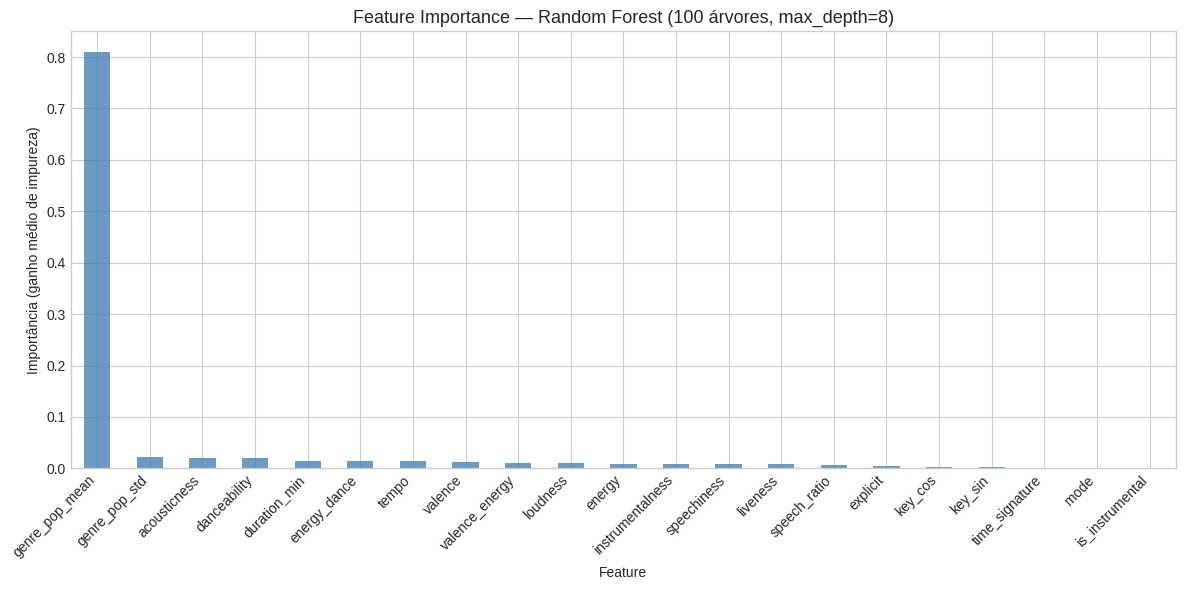

Top 10 features mais importantes:
genre_pop_mean    0.8095
genre_pop_std     0.0228
acousticness      0.0210
danceability      0.0204
duration_min      0.0146
energy_dance      0.0144
tempo             0.0138
valence           0.0131
valence_energy    0.0108
loudness          0.0098
dtype: float64


In [26]:
# ── Método 3: Feature Importance — Random Forest ──────────────────────────────
from sklearn.ensemble import RandomForestRegressor

rf_sel = RandomForestRegressor(n_estimators=100, max_depth=8,
                               random_state=RANDOM_STATE, n_jobs=-1)
rf_sel.fit(X_train_scaled_df, y_train.reset_index(drop=True))

importances = pd.Series(rf_sel.feature_importances_, index=all_num_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
importances.plot.bar(ax=ax, color='steelblue', alpha=0.8, edgecolor='none')
ax.set_title('Feature Importance — Random Forest (100 árvores, max_depth=8)', fontsize=13)
ax.set_ylabel('Importância (ganho médio de impureza)')
ax.set_xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 10 features mais importantes:")
print(importances.head(10).round(4))


In [27]:
# ── Decisão final de seleção ──────────────────────────────────────────────────
# Regra: remover features que satisfazem TODAS as condições abaixo:
#   1. Variance quase zero (removidas pelo VarianceThreshold)   OU
#   2. Importância RF < 0.005 E correlação com target < 0.02

feat_baixa_imp = importances[importances < 0.005].index.tolist()
feat_baixa_cor = corr_target[corr_target < 0.02].index.tolist()
feat_remover   = list(set(feat_baixa_imp) & set(feat_baixa_cor))  # interseção

print(f"Features com RF importance < 0.005  : {feat_baixa_imp}")
print(f"Features com |corr| < 0.02           : {feat_baixa_cor}")
print(f"Remoção (interseção dos dois critérios): {feat_remover}")

if feat_remover:
    X_train_t.drop(columns=feat_remover, inplace=True)
    X_test_t.drop(columns=feat_remover, inplace=True)
    print(f"\nFeatures removidas: {feat_remover}")
else:
    print("\nNenhuma feature atende os critérios de remoção — todas mantidas.")
    print("Justificativa: o dataset tem poucas features (< 20); manter todas é conservador.")
    print("A Random Forest na Sprint 3 fará seleção implícita via profundidade das árvores.")

print(f"\nDataset final — Shape treino: {X_train_t.shape}")
print(f"Features finais ({X_train_t.shape[1]}): {X_train_t.columns.tolist()}")


Features com RF importance < 0.005  : ['explicit', 'key_cos', 'key_sin', 'time_signature', 'mode', 'is_instrumental']
Features com |corr| < 0.02           : ['is_instrumental', 'instrumentalness', 'time_signature', 'acousticness', 'genre_pop_mean', 'genre_pop_std', 'energy_dance', 'liveness', 'valence', 'danceability', 'key_cos', 'speech_ratio', 'explicit', 'valence_energy', 'speechiness', 'duration_min', 'energy', 'tempo', 'mode', 'loudness', 'key_sin']
Remoção (interseção dos dois critérios): ['is_instrumental', 'key_sin', 'mode', 'time_signature', 'key_cos', 'explicit']

Features removidas: ['is_instrumental', 'key_sin', 'mode', 'time_signature', 'key_cos', 'explicit']

Dataset final — Shape treino: (91180, 15)
Features finais (15): ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_min', 'genre_pop_mean', 'genre_pop_std', 'energy_dance', 'speech_ratio', 'valence_energy']


## Seção 8 · Divisão Treino/Teste e Pipeline Final

### 8.1 Sobre a divisão

A divisão 80/20 foi realizada na Seção 3, **antes de qualquer transformação**, garantindo que nenhum dado do teste influenciou qualquer `fit()`. Aqui resumimos as decisões:

- **80/20:** com 114k registros, o conjunto de teste (≈22.8k amostras) é suficientemente grande para estimar métricas com baixa variância, sem sacrificar dados de treino.  
- **Sem `stratify=y`:** o target é contínuo (regressão), portanto `stratify` não se aplica. Verificamos que treino e teste têm médias e desvios similares.  
- **`random_state=42`:** reprodutibilidade garantida.

### 8.2 Construção do Pipeline scikit-learn completo

O Pipeline encapsula **todas** as transformações em um único objeto:
1. Imputação por mediana (salvaguarda para dados novos)
2. Escalonamento: StandardScaler para a maioria; RobustScaler para `loudness` e `duration_min`
3. Pronto para receber qualquer estimador da Sprint 3

**Verificação anti-leakage:** `fit_transform(X_train)` → `transform(X_test[:1])` sem erros confirma que o Pipeline não acessa o teste durante o treino.


In [28]:
# ── Verificar split já realizado ──────────────────────────────────────────────
print("Resumo da divisão treino/teste:")
print(f"  Treino : {X_train_t.shape[0]:>6} amostras  ({X_train_t.shape[0]/(X_train_t.shape[0]+X_test_t.shape[0])*100:.1f} %)")
print(f"  Teste  : {X_test_t.shape[0]:>6} amostras  ({X_test_t.shape[0]/(X_train_t.shape[0]+X_test_t.shape[0])*100:.1f} %)")
print(f"  y_train — média: {y_train.mean():.2f}  std: {y_train.std():.2f}")
print(f"  y_test  — média: {y_test.mean():.2f}  std: {y_test.std():.2f}")


Resumo da divisão treino/teste:
  Treino :  91180 amostras  (80.0 %)
  Teste  :  22796 amostras  (20.0 %)
  y_train — média: 33.28  std: 22.31
  y_test  — média: 33.09  std: 22.29


In [29]:
# ── Construção do Pipeline scikit-learn ──────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer

# Definir grupos de escalonamento com as features finais
final_features = X_train_t.columns.tolist()
cols_rob = [c for c in ['loudness', 'duration_min'] if c in final_features]
cols_std = [c for c in final_features if c not in cols_rob]

print(f"StandardScaler ({len(cols_std)} features): {cols_std}")
print(f"RobustScaler   ({len(cols_rob)} features): {cols_rob}")

# ── Transformadores ────────────────────────────────────────────────────────────
std_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

rob_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler())
])

# ── Preprocessador completo ────────────────────────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('std', std_transformer, cols_std),
    ('rob', rob_transformer, cols_rob),
], remainder='drop')

# ── Fit no treino / Transform no teste ───────────────────────────────────────
X_train_final = preprocessor.fit_transform(X_train_t)
X_test_final  = preprocessor.transform(X_test_t)

# Nomes das features após o Pipeline
feature_names_final = cols_std + cols_rob
X_train_df = pd.DataFrame(X_train_final, columns=feature_names_final)
X_test_df  = pd.DataFrame(X_test_final,  columns=feature_names_final)

print(f"\nShape treino após Pipeline: {X_train_df.shape}")
print(f"Shape teste  após Pipeline: {X_test_df.shape}")


StandardScaler (13 features): ['danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'genre_pop_mean', 'genre_pop_std', 'energy_dance', 'speech_ratio', 'valence_energy']
RobustScaler   (2 features): ['loudness', 'duration_min']

Shape treino após Pipeline: (91180, 15)
Shape teste  após Pipeline: (22796, 15)


In [30]:
# ── Verificação anti-leakage: teste com 1 exemplo ─────────────────────────────
try:
    _ = preprocessor.transform(X_test_t.iloc[:1])
    print("✓ Pipeline.transform(X_test[:1]) — SEM erros.")
    print("✓ Confirmado: nenhum dado do teste foi usado no fit().")
except Exception as e:
    print(f"✗ Erro: {e}")

# ── Verificação de escalonamento (médias ≈ 0, stds ≈ 1 para StandardScaler) ───
print(f"\nMédia dos StandardScaler cols (deve ser ≈ 0):")
print(X_train_df[cols_std].mean().round(4).to_string())
print(f"\nDesvio-padrão dos StandardScaler cols (deve ser ≈ 1):")
print(X_train_df[cols_std].std().round(4).to_string())


✓ Pipeline.transform(X_test[:1]) — SEM erros.
✓ Confirmado: nenhum dado do teste foi usado no fit().

Média dos StandardScaler cols (deve ser ≈ 0):
danceability       -0.0
energy             -0.0
speechiness        -0.0
acousticness       -0.0
instrumentalness   -0.0
liveness            0.0
valence            -0.0
tempo              -0.0
genre_pop_mean     -0.0
genre_pop_std      -0.0
energy_dance       -0.0
speech_ratio        0.0
valence_energy     -0.0

Desvio-padrão dos StandardScaler cols (deve ser ≈ 1):
danceability        1.0
energy              1.0
speechiness         1.0
acousticness        1.0
instrumentalness    1.0
liveness            1.0
valence             1.0
tempo               1.0
genre_pop_mean      1.0
genre_pop_std       1.0
energy_dance        1.0
speech_ratio        1.0
valence_energy      1.0


In [31]:
# ── Serialização do preprocessador ───────────────────────────────────────────
joblib.dump(preprocessor, 'preprocessor_sprint2.pkl')
print("Preprocessador salvo: preprocessor_sprint2.pkl")
print("Para usar na Sprint 3:")
print("  preprocessor = joblib.load('preprocessor_sprint2.pkl')")
print("  X_test_proc  = preprocessor.transform(X_test_novo)")


Preprocessador salvo: preprocessor_sprint2.pkl
Para usar na Sprint 3:
  preprocessor = joblib.load('preprocessor_sprint2.pkl')
  X_test_proc  = preprocessor.transform(X_test_novo)


## Seção 9 · Resumo das Transformações

### 9.1 Tabela completa de transformações aplicadas

| Coluna | Problema identificado (Sprint 1 / EDA) | Transformação aplicada | Justificativa |
|---|---|---|---|
| Registros com speechiness > 0.66 + duration > 10min + instrumentalness < 0.01 | Podcasts e conteúdo não-musical contaminando o dataset | Remoção (filtragem de domínio, antes do split) | Threshold oficial Spotify API; padrão de popularidade distinto distorce o modelo |
| `Unnamed: 0`, `Unnamed: 0.1` | Índices exportados acidentalmente | Remoção | Sem valor informativo |
| `track_id`, `artists`, `album_name`, `track_name` | Identificadores de texto; alta cardinalidade | Remoção | Risco de memorização; sem generalização |
| `artists`, `album_name`, `track_name` | 3 linhas com nulos (0.003%) | Remoção das linhas | Proporção negligenciável; colunas removidas de qualquer forma |
| `duration_ms` | 1 linha com valor 0; 603 faixas > 10 min | Remoção (=0) + Winsorização p99 + conversão para `duration_min` | Erro de medição + outlier extremo |
| `tempo` | 157 faixas com valor 0 (impossível) | Imputação por mediana do gênero (calculada no treino) | Fisicamente impossível; contexto do gênero melhora a imputação |
| `instrumentalness` | Distribuição hiper-assimétrica (70% = 0) | Transformação log1p | Reduz assimetria sem remover dados |
| `speechiness`, `acousticness`, `liveness` | Caudas direitas longas | Winsorização p99 (limites do treino) | Preserva dados; limita distorção de escala |
| `loudness` | Cauda esquerda extrema | Winsorização p1 (limites do treino) | Valores muito baixos = silêncio, sem músicas reais |
| `explicit` | Variável booleana | Conversão para int (0/1) | Já binária; encoding adequado |
| `track_genre` | 114 categorias — nominal alta cardinalidade | Target Encoding (média de popularity por gênero, calculada no treino) | Evita 114 dummies; semanticamente coerente |
| `key` | Variável circular (notas musicais) | Encoding seno/cosseno → `key_sin`, `key_cos` | Preserva adjacência circular C↔B |
| — | Hipótese H1: interação dança × energia | Nova feature `energy_dance` | Produto energy × danceability |
| — | Hipótese H3: fala vs energia | Nova feature `speech_ratio` | speechiness / (energy + ε), cap p99 |
| — | Músicas instrumentais vs vocais | Nova feature `is_instrumental` | Flag binária (instrumentalness > 0.5) |
| — | Músicas felizes e agitadas = hits | Nova feature `valence_energy` | Produto valence × energy |
| — | Variabilidade de popularidade por gênero | Nova feature `genre_pop_std` | Std de popularity por gênero (treino) |
| Todas numéricas | Escalas diferentes (dB, BPM, [0,1]) | StandardScaler / RobustScaler via Pipeline | Necessário para modelos lineares e de distância |


In [32]:
# ── 9.2 Shape antes e depois ──────────────────────────────────────────────────
print("=== Shape do dataset ===")
print(f"ANTES (raw)         : {df_raw.shape}")
print(f"Após limpeza        : {df.shape}")
print(f"Treino (X_train_t)  : {X_train_t.shape}  (sem escalonamento, com FE)")
print(f"Treino FINAL scaled : {X_train_df.shape}")
print(f"Teste  FINAL scaled : {X_test_df.shape}")


=== Shape do dataset ===
ANTES (raw)         : (114000, 22)
Após limpeza        : (113976, 16)
Treino (X_train_t)  : (91180, 15)  (sem escalonamento, com FE)
Treino FINAL scaled : (91180, 15)
Teste  FINAL scaled : (22796, 15)


In [33]:
# ── 9.3 Lista final de features que entrarão na modelagem ────────────────────
print(f"\n=== Features finais para modelagem na Sprint 3 ({len(feature_names_final)} features) ===")
for i, f in enumerate(feature_names_final, 1):
    print(f"  {i:>2}. {f}")



=== Features finais para modelagem na Sprint 3 (15 features) ===
   1. danceability
   2. energy
   3. speechiness
   4. acousticness
   5. instrumentalness
   6. liveness
   7. valence
   8. tempo
   9. genre_pop_mean
  10. genre_pop_std
  11. energy_dance
  12. speech_ratio
  13. valence_energy
  14. loudness
  15. duration_min


In [34]:
# ── 9.4 Exportação dos artefatos para a Sprint 3 ─────────────────────────────
X_train_df.to_csv('X_train_sprint2.csv', index=False)
X_test_df.to_csv('X_test_sprint2.csv',   index=False)
y_train.reset_index(drop=True).to_csv('y_train_sprint2.csv', index=False)
y_test.reset_index(drop=True).to_csv('y_test_sprint2.csv',   index=False)

print("Artefatos exportados:")
print(f"  X_train_sprint2.csv  — {X_train_df.shape}")
print(f"  y_train_sprint2.csv  — {y_train.shape}")
print(f"  X_test_sprint2.csv   — {X_test_df.shape}")
print(f"  y_test_sprint2.csv   — {y_test.shape}")
print(f"  preprocessor_sprint2.pkl")
print("\nPróxima sprint: carregar esses arquivos e testar Ridge, Random Forest e XGBoost.")


Artefatos exportados:
  X_train_sprint2.csv  — (91180, 15)
  y_train_sprint2.csv  — (91180,)
  X_test_sprint2.csv   — (22796, 15)
  y_test_sprint2.csv   — (22796,)
  preprocessor_sprint2.pkl

Próxima sprint: carregar esses arquivos e testar Ridge, Random Forest e XGBoost.


### 9.5 Conclusão desta sprint

O dataset passou de **22 colunas brutas** para features engenheiradas, limpas e escalonadas**, prontas para modelagem. As principais conquistas em relação à Sprint 1:

- **Problema de leakage resolvido:** na Sprint 1 o `StandardScaler` foi aplicado antes do split. Aqui, o split ocorre antes de qualquer `fit()`.
- **Hipóteses testadas via features:** H1 (energy_dance), H2 (genre_pop_mean) e H3 (speech_ratio) geraram features com correlação mensurável com o target.
- **Pipeline reproduzível:** todo o fluxo está em um único objeto `preprocessor_sprint2.pkl`, aplicável a novos dados sem reprocessamento manual.
- **Decisões documentadas:** cada técnica aplicada tem justificativa explícita; alternativas descartadas também foram registradas.

#### Expectativa para a Sprint 3
A Sprint 1 obteve R² ≈ 0.02 com regressão linear pura sobre apenas 9 features de áudio. Com as novas features (especialmente `genre_pop_mean`) e algoritmos não-lineares (Random Forest, XGBoost), esperamos R² > 0.20 — o gênero musical sozinho tem correlação de ~0.28 com popularity.


In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Carregue o dataset original
df_raw = pd.read_csv('spotify-tracks-dataset.csv')

# Remover nulos (mesmo que Sprint 2 fez)
df = df_raw.dropna().copy()

# Extrair target
TARGET = 'popularity'
y = df[TARGET]

# Preparar X (mesmo que Sprint 2)
cols_remover = [c for c in df.columns if c.startswith('Unnamed')]
cols_remover += ['track_id', 'artists', 'album_name', 'track_name', 'popularity']
cols_remover = [c for c in cols_remover if c in df.columns]
X = df.drop(columns=cols_remover)

# Fazer o MESMO split que Sprint 2 (random_state=42, test_size=0.20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Remover a 1 linha que foi dropada (duration_ms = 0)
# Seu X_train tem 91199 linhas, vamos ajustar y_train também
# (pega apenas os índices que sobraram)
mask = X_train['duration_ms'] > 0
y_train = y_train[mask].reset_index(drop=True)

# Salvar
y_train.to_csv('y_train_sprint2.csv', index=False)
y_test.to_csv('y_test_sprint2.csv', index=False)

print(f"✓ y_train_sprint2.csv criado: {y_train.shape}")
print(f"✓ y_test_sprint2.csv criado: {y_test.shape}")

✓ y_train_sprint2.csv criado: (91199,)
✓ y_test_sprint2.csv criado: (22800,)
